# Force Validation — Ascending / Descending Sweep
For each angle: ascending magnitudes then descending. Two polar semicircle plots.

## Cell 1 — Load Data

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d

SESSION_DIR = '/home/sujith/Documents/NOARK_backbone/csv_data/june_19_autosweep_t1'  # UPDATE THIS

lc  = pd.read_csv(os.path.join(SESSION_DIR, 'loadcell.csv'), parse_dates=['timestamp'])
gui = pd.read_csv(os.path.join(SESSION_DIR, 'gui.csv'),      parse_dates=['timestamp'])

lc  = lc.sort_values('timestamp').reset_index(drop=True)
gui = gui.sort_values('timestamp').reset_index(drop=True)

if len(lc) < 2 or len(gui) < 2:
    raise ValueError('Empty CSV — check SESSION_DIR: ' + SESSION_DIR)

lc_hz  = len(lc)  / (lc['timestamp'].iloc[-1]  - lc['timestamp'].iloc[0]).total_seconds()
gui_hz = len(gui) / (gui['timestamp'].iloc[-1] - gui['timestamp'].iloc[0]).total_seconds()
print(f'loadcell : {lc_hz:.1f} Hz  ({len(lc)} rows)')
print(f'gui      : {gui_hz:.1f} Hz  ({len(gui)} rows)')

loadcell : 349.2 Hz  (195494 rows)
gui      : 181.0 Hz  (101335 rows)


## Cell 2 — Resample to 100 Hz

In [8]:
RESAMPLE_HZ = 100

t0    = min(lc['timestamp'].iloc[0], gui['timestamp'].iloc[0])
lc_t  = (lc['timestamp']  - t0).dt.total_seconds().values
gui_t = (gui['timestamp'] - t0).dt.total_seconds().values

t_start = max(lc_t[0],  gui_t[0])
t_end   = min(lc_t[-1], gui_t[-1])
t_grid     = np.arange(t_start, t_end - 0.5 / RESAMPLE_HZ, 1.0 / RESAMPLE_HZ)
timestamps = t0 + pd.to_timedelta(t_grid, unit='s')

lc_new = {'timestamp': timestamps}
for col in ['Fx', 'Fy']:
    lc_new[col] = interp1d(lc_t, lc[col].values, kind='linear', bounds_error=True)(t_grid)
lc = pd.DataFrame(lc_new)

gui_new = {'timestamp': timestamps}
for col in ['magnitude', 'direction', 'Fx', 'Fz']:
    gui_new[col] = interp1d(gui_t, gui[col].values, kind='previous', bounds_error=True)(t_grid)

# new columns logged by updated Ad_sweep (sweep_step, sweep_dir, sweep_cycle)
HAS_SWEEP_COLS = 'sweep_step' in gui.columns
if HAS_SWEEP_COLS:
    for col in ['sweep_step', 'sweep_cycle']:
        gui_new[col] = interp1d(gui_t, gui[col].values.astype(float), kind='previous',
                                bounds_error=True)(t_grid).astype(int)
    gui_idx = np.searchsorted(gui_t, t_grid, side='right') - 1
    gui_new['sweep_dir'] = gui['sweep_dir'].values[np.clip(gui_idx, 0, len(gui_t) - 1)]

gui = pd.DataFrame(gui_new)
print(f'Resampled: {len(lc)} rows @ {RESAMPLE_HZ} Hz  (sweep cols: {HAS_SWEEP_COLS})')

Resampled: 55985 rows @ 100 Hz  (sweep cols: True)


## Cell 3 — Merge, Detect Steps

In [ ]:
HOLD_TIME  = 2.0
REST_TIME  = 4.0
STABLE_WIN = 1.0
MAG_LIST   = [5.0, 10.0, 15.0, 24.0]

lc_merge = lc[['timestamp', 'Fx', 'Fy']].rename(
    columns={'Fx': 'measured_Fx', 'Fy': 'measured_Fy'})

gui_cols = ['timestamp', 'magnitude', 'direction', 'Fx', 'Fz']
if HAS_SWEEP_COLS:
    gui_cols += ['sweep_step', 'sweep_dir', 'sweep_cycle']

df = pd.merge_asof(gui[gui_cols], lc_merge, on='timestamp', direction='nearest')
df = df.rename(columns={'Fx': 'given_Fx', 'Fz': 'given_Fz'})

df['measured_magnitude'] = np.sqrt(df['measured_Fx']**2 + df['measured_Fy']**2)
df['measured_direction'] = np.degrees(np.arctan2(df['measured_Fy'], df['measured_Fx']))
df['t_sec'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds()

if HAS_SWEEP_COLS:
    df['step'] = df['sweep_step'].astype(int)
    # drop pre-sweep (step=-1) and rest steps — rest has 4s duration, not HOLD_TIME
    df = df[(df['step'] >= 0) & (df['sweep_dir'] != 'rest')].reset_index(drop=True)
else:
    # fallback for old data: diff detection + time split for 24→24 transition
    step_change = (df['magnitude'].diff().abs() > 0.5) | (df['direction'].diff().abs() > 1.0)
    df['step_raw'] = step_change.cumsum()
    t_rel = df.groupby('step_raw')['t_sec'].transform(lambda x: x - x.min())
    time_chunk = (t_rel / HOLD_TIME).astype(int)
    df['step'] = df.groupby(['step_raw', time_chunk]).ngroup()

# true time since the actual command fired
step_start_t = df.groupby('step')['t_sec'].transform('min')
df['t_in_step'] = df['t_sec'] - step_start_t

# truncate each force step at HOLD_TIME
df = df[df['t_in_step'] <= HOLD_TIME].reset_index(drop=True)

print(f'Force steps: {df["step"].nunique()},  rows: {len(df)}')

## Cell 4 — Stable Window + Classify Ascending / Descending

In [10]:
MAG_TOL = 1.0

# stable window = last STABLE_WIN seconds since actual command fired
stable = df[df['t_in_step'] >= HOLD_TIME - STABLE_WIN].copy()
stable = stable[stable['magnitude'].apply(
    lambda m: any(abs(m - mg) < MAG_TOL for mg in MAG_LIST))]

print(f'Stable rows: {len(stable)}  (STABLE_WIN={STABLE_WIN}s)')

if HAS_SWEEP_COLS:
    summary = stable.groupby('step').agg(
        angle      = ('direction',          'first'),
        given_mag  = ('magnitude',          'first'),
        mean_meas  = ('measured_magnitude', 'mean'),
        mean_dir   = ('measured_direction', 'mean'),
        sweep_type = ('sweep_dir',          'first'),
        cycle      = ('sweep_cycle',        'first'),
        n          = ('magnitude',          'count'),
    ).reset_index()
else:
    summary = stable.groupby('step').agg(
        angle     = ('direction',          'first'),
        given_mag = ('magnitude',          'first'),
        mean_meas = ('measured_magnitude', 'mean'),
        mean_dir  = ('measured_direction', 'mean'),
        n         = ('magnitude',          'count'),
    ).reset_index()

    def _label_sweep(group):
        g = group.sort_values('step').copy()
        mags = g['given_mag'].values
        sweep_types, cycle_nums, cycle = [], [], 0
        for i, cur in enumerate(mags):
            prev = mags[i-1] if i > 0 else None
            nxt  = mags[i+1] if i < len(mags)-1 else None
            if prev is None or cur > prev:       stype = 'asc'
            elif cur < prev:                      stype = 'desc'
            elif nxt is not None and nxt < cur:  stype = 'desc'
            elif nxt is not None and nxt > cur:  stype = 'asc'
            else:                                 stype = sweep_types[-1] if sweep_types else 'asc'
            if sweep_types and sweep_types[-1] == 'desc' and stype == 'asc':
                cycle += 1
            sweep_types.append(stype); cycle_nums.append(cycle)
        g['sweep_type'] = sweep_types; g['cycle'] = cycle_nums
        return g

    tmp = summary.copy()
    tmp['angle_group'] = tmp['angle'].round(1)
    summary = (tmp.groupby('angle_group', group_keys=False)
               .apply(_label_sweep)
               .sort_values('step').reset_index(drop=True))

summary['mag_err']     = summary['mean_meas'] - summary['given_mag']
summary['dir_err']     = summary['mean_dir']  - summary['angle']
summary['angle_group'] = summary['angle'].round(1)

n_asc  = (summary['sweep_type'] == 'asc').sum()
n_desc = (summary['sweep_type'] == 'desc').sum()
n_cyc  = int(summary['cycle'].max()) + 1
print(f'Ascending: {n_asc} steps,  Descending: {n_desc} steps,  Cycles: {n_cyc}\n')

print('{:>5} | {:>10} | {:>10} | {:>14} | {:>10} | {:>12} | {:>10} | {:>5} | {:>6}'.format(
      'Step', 'Angle', 'Given (N)', 'Meas Mag (N)', 'Mag Err', 'Meas Dir', 'Dir Err', 'Cyc', 'Sweep'))
print('-' * 98)
prev_angle = None
for _, row in summary.iterrows():
    if prev_angle is not None and abs(row['angle'] - prev_angle) > 1:
        print()
    print('{:>5} | {:>10.1f} | {:>10.1f} | {:>14.3f} | {:>10.3f} | {:>12.1f} | {:>10.3f} | {:>5} | {:>6}'.format(
          int(row['step']), row['angle'], row['given_mag'], row['mean_meas'],
          row['mag_err'], row['mean_dir'], row['dir_err'], int(row['cycle']), row['sweep_type']))
    prev_angle = row['angle']

Stable rows: 27981  (STABLE_WIN=1.0s)
Ascending: 140 steps,  Descending: 140 steps,  Cycles: 5

 Step |      Angle |  Given (N) |   Meas Mag (N) |    Mag Err |     Meas Dir |    Dir Err |   Cyc |  Sweep
--------------------------------------------------------------------------------------------------
    0 |     -129.1 |        5.0 |          3.272 |     -1.728 |       -136.5 |     -7.373 |     0 |    asc
    1 |     -129.1 |       10.0 |          6.088 |     -3.912 |       -136.5 |     -7.332 |     0 |    asc
    2 |     -129.1 |       15.0 |         11.606 |     -3.394 |       -136.2 |     -7.069 |     0 |    asc
    3 |     -129.1 |       24.0 |         18.066 |     -5.934 |       -134.9 |     -5.792 |     0 |    asc
    4 |     -129.1 |       24.0 |         17.460 |     -6.540 |       -134.9 |     -5.737 |     0 |   desc
    5 |     -129.1 |       15.0 |         15.392 |      0.392 |       -135.4 |     -6.274 |     0 |   desc
    6 |     -129.1 |       10.0 |         10.134 |      

## Cell 4b — Repeatability (std of error across cycles)


Ascending — Repeatability summary

     Angle |  Given (N) |  Mean MagErr |   Std MagErr |  Mean DirErr |   Std DirErr |   Cycles
-----------------------------------------------------------------------------------------------
    -129.1 |        5.0 |       -0.302 |        0.813 |        -7.74 |         0.27 |        5
    -129.1 |       10.0 |       -2.554 |        0.765 |        -7.33 |         0.06 |        5
    -129.1 |       15.0 |       -3.125 |        0.284 |        -6.87 |         0.24 |        5
    -129.1 |       24.0 |       -6.790 |        0.614 |        -5.45 |         0.25 |        5

    -115.8 |        5.0 |        0.268 |        0.328 |        -8.09 |         5.41 |        5
    -115.8 |       10.0 |       -2.394 |        0.162 |        -3.31 |         2.08 |        5
    -115.8 |       15.0 |       -3.486 |        0.259 |        -3.33 |         0.48 |        5
    -115.8 |       24.0 |       -6.222 |        0.104 |        -3.04 |         0.48 |        5

    -102.6 

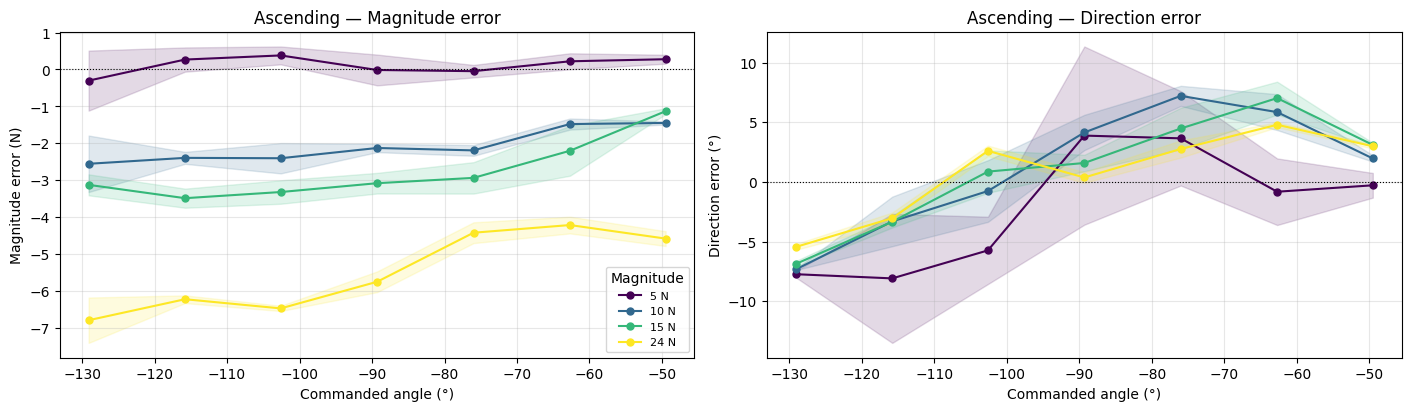


Descending — Repeatability summary

     Angle |  Given (N) |  Mean MagErr |   Std MagErr |  Mean DirErr |   Std DirErr |   Cycles
-----------------------------------------------------------------------------------------------
    -129.1 |        5.0 |       -0.090 |        0.167 |        -7.74 |         0.20 |        5
    -129.1 |       10.0 |       -0.020 |        0.276 |        -6.50 |         0.27 |        5
    -129.1 |       15.0 |       -0.063 |        0.274 |        -6.24 |         0.06 |        5
    -129.1 |       24.0 |       -6.821 |        0.748 |        -5.50 |         0.20 |        5

    -115.8 |        5.0 |        0.210 |        0.412 |        -4.73 |         2.07 |        5
    -115.8 |       10.0 |        0.396 |        0.221 |        -4.39 |         0.44 |        5
    -115.8 |       15.0 |       -0.603 |        0.167 |        -4.97 |         0.89 |        5
    -115.8 |       24.0 |       -6.394 |        0.121 |        -2.88 |         0.64 |        5

    -102.6

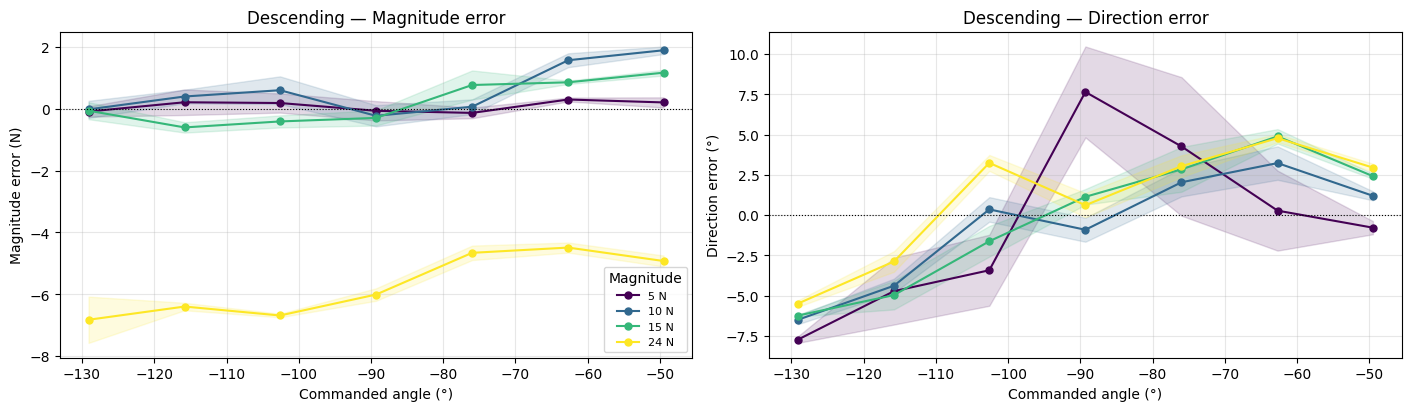

In [11]:
%matplotlib inline

mag_levels = sorted(summary['given_mag'].unique())
colors     = plt.cm.viridis(np.linspace(0, 1, len(mag_levels)))

for sweep_label, sweep_tag in [('Ascending', 'asc'), ('Descending', 'desc')]:
    sub = summary[summary['sweep_type'] == sweep_tag]
    if sub.empty:
        continue

    rep = (sub.groupby(['angle_group', 'given_mag'], sort=True)
              .agg(
                  mean_mag_err = ('mag_err', 'mean'),
                  std_mag_err  = ('mag_err', 'std'),
                  mean_dir_err = ('dir_err', 'mean'),
                  std_dir_err  = ('dir_err', 'std'),
                  n_cycles     = ('cycle',   'nunique'),
              )
              .reset_index())

    print(f'\n{sweep_label} — Repeatability summary\n')
    print('{:>10} | {:>10} | {:>12} | {:>12} | {:>12} | {:>12} | {:>8}'.format(
          'Angle', 'Given (N)', 'Mean MagErr', 'Std MagErr', 'Mean DirErr', 'Std DirErr', 'Cycles'))
    print('-' * 95)
    prev_angle = None
    for _, row in rep.iterrows():
        if prev_angle is not None and abs(row['angle_group'] - prev_angle) > 1:
            print()
        print('{:>10.1f} | {:>10.1f} | {:>12.3f} | {:>12.3f} | {:>12.2f} | {:>12.2f} | {:>8}'.format(
              row['angle_group'], row['given_mag'],
              row['mean_mag_err'], row['std_mag_err'],
              row['mean_dir_err'], row['std_dir_err'],
              int(row['n_cycles'])))
        prev_angle = row['angle_group']

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
    for ax, err_col, std_col, ylabel, title in [
            (axes[0], 'mean_mag_err', 'std_mag_err', 'Magnitude error (N)', 'Magnitude error'),
            (axes[1], 'mean_dir_err', 'std_dir_err', 'Direction error (°)', 'Direction error')]:
        for mag, color in zip(mag_levels, colors):
            row = rep[rep['given_mag'] == mag].sort_values('angle_group')
            if row.empty: continue
            x   = row['angle_group'].values
            y   = row[err_col].values
            std = row[std_col].fillna(0).values
            ax.plot(x, y, color=color, marker='o', ms=5, label=f'{int(mag)} N')
            ax.fill_between(x, y - std, y + std, color=color, alpha=0.15)
        ax.axhline(0, color='black', lw=0.8, ls=':')
        ax.set_xlabel('Commanded angle (°)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{sweep_label} — {title}')
        ax.grid(True, alpha=0.3)
    axes[0].legend(title='Magnitude', fontsize=8)
    plt.savefig(os.path.join(SESSION_DIR, f'repeatability_{sweep_tag}.png'), dpi=150, bbox_inches='tight')
    plt.show()

## Cell 5 — Polar Semicircle Plots

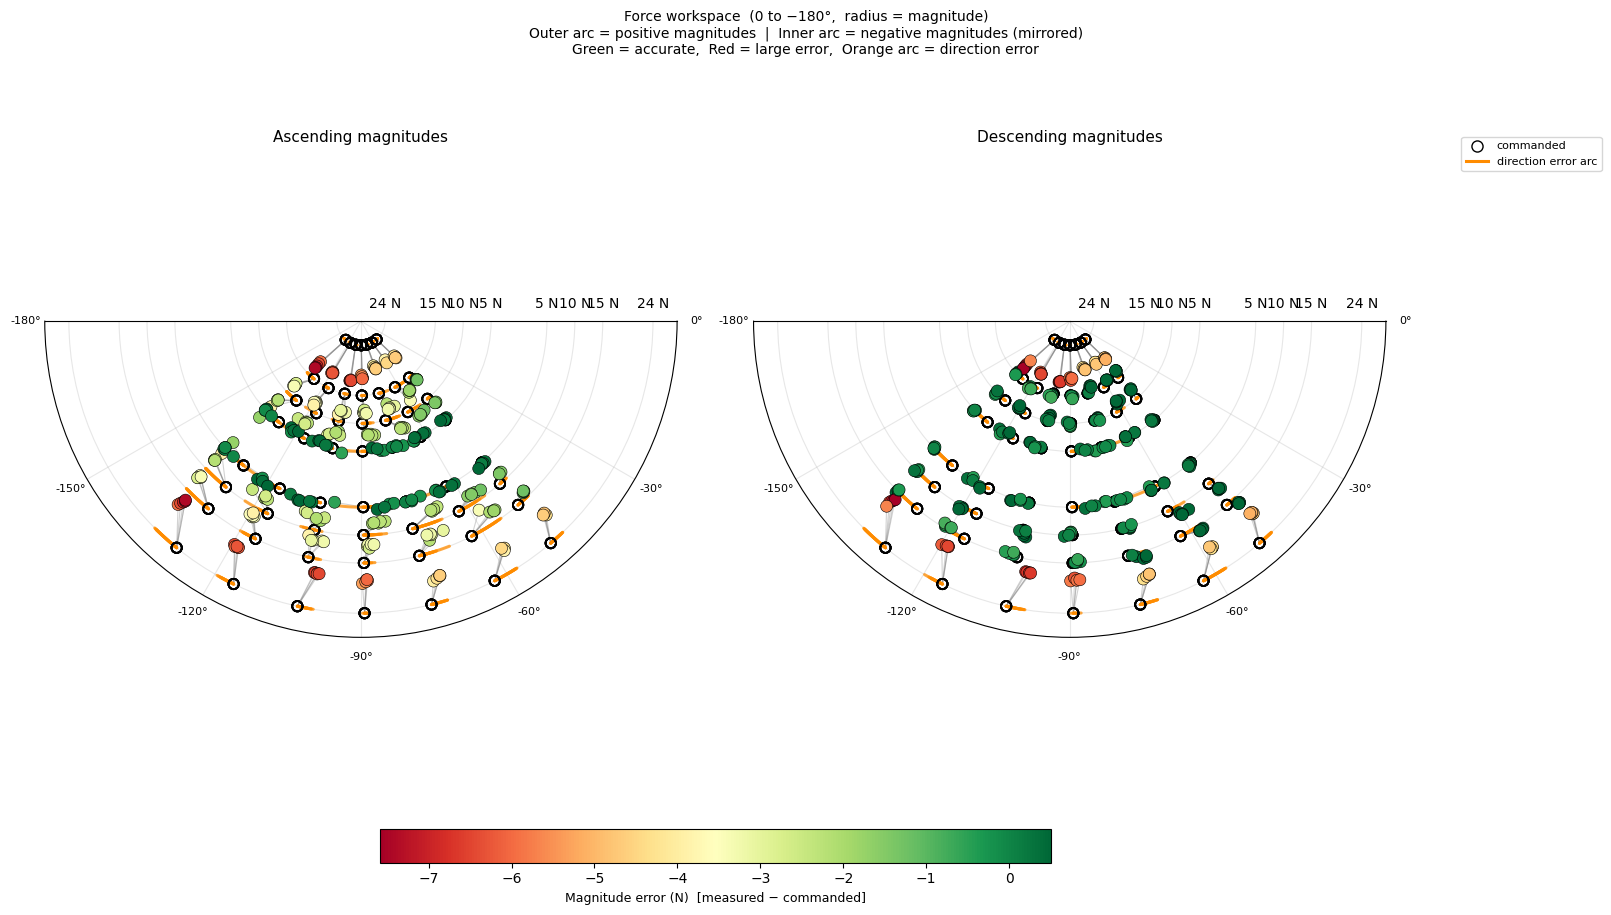

In [12]:
%matplotlib inline

asc  = summary[summary['sweep_type'] == 'asc']
desc = summary[summary['sweep_type'] == 'desc']

err_min = min(summary['mag_err'].min(), -0.5)
r_max   = max(MAG_LIST) * 1.18

fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(16, 9),
                         constrained_layout=True)
titles  = ['Ascending magnitudes', 'Descending magnitudes']
subsets = [asc, desc]

sc_last = None
for ax, subset, title in zip(axes, subsets, titles):
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(-1)
    ax.set_thetamin(0)
    ax.set_thetamax(180)
    ax.set_rlim(-r_max, r_max)

    r_ticks = sorted([-m for m in MAG_LIST] + list(MAG_LIST))
    ax.set_rticks(r_ticks)
    ax.set_yticklabels([f'{abs(r):.0f} N' for r in r_ticks], fontsize=7)

    tick_deg = np.arange(0, 181, 30)
    ax.set_xticks(np.radians(tick_deg))
    ax.set_xticklabels([f'{-int(a)}°' for a in tick_deg], fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_title(title, pad=15, fontsize=11)

    if subset.empty:
        continue

    cmd_theta  = np.radians(-subset['angle'].values)
    cmd_r      = subset['given_mag'].values
    meas_theta = np.radians(-subset['mean_dir'].values)
    meas_r     = subset['mean_meas'].values
    mag_errors = subset['mag_err'].values
    dir_errors = subset['dir_err'].values

    for sign in [+1, -1]:
        cr = sign * cmd_r
        mr = sign * meas_r

        for ct, _cr, mt, _mr in zip(cmd_theta, cr, meas_theta, mr):
            ax.plot([ct, mt], [_cr, _mr], color='grey', lw=0.8, alpha=0.35, zorder=2)

        for ct, _cr, derr in zip(cmd_theta, cr, dir_errors):
            arc_end    = ct - np.radians(derr)
            arc_thetas = np.linspace(ct, arc_end, 40)
            ax.plot(arc_thetas, np.full_like(arc_thetas, _cr),
                    color='darkorange', lw=2.2, alpha=0.75, solid_capstyle='round', zorder=3)

        ax.scatter(cmd_theta, cr, s=55, facecolors='none', edgecolors='black',
                   linewidths=1.3, zorder=5)

        sc_last = ax.scatter(meas_theta, mr, s=75, c=mag_errors,
                             cmap='RdYlGn', vmin=err_min, vmax=0.5,
                             zorder=6, edgecolors='black', linewidths=0.4)

    theta_sep = np.linspace(0, np.pi, 200)
    ax.plot(theta_sep, np.zeros_like(theta_sep), color='white', lw=1.2, alpha=0.5, zorder=1)

if sc_last is not None:
    cbar = fig.colorbar(sc_last, ax=axes.tolist(), orientation='horizontal', shrink=0.5, pad=0.04)
    cbar.set_label('Magnitude error (N)  [measured − commanded]', fontsize=9)

legend_handles = [
    Line2D([0],[0], marker='o', color='none', markeredgecolor='black',
           markersize=8, label='commanded'),
    Line2D([0],[0], color='darkorange', lw=2.2, label='direction error arc'),
]
axes[1].legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(1.35, 1.05), fontsize=8)

fig.suptitle(
    'Force workspace  (0 to −180°,  radius = magnitude)\n'
    'Outer arc = positive magnitudes  |  Inner arc = negative magnitudes (mirrored)\n'
    'Green = accurate,  Red = large error,  Orange arc = direction error',
    fontsize=10)

plt.savefig(os.path.join(SESSION_DIR, 'sweep_polar.png'), dpi=150, bbox_inches='tight')
plt.show()